<a href="https://colab.research.google.com/github/Sibitenda/Diploma/blob/main/solid_modeling_python_notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solid Modeling Concepts in Python (Colab)

This notebook demonstrates core solid modeling ideas using Python approximations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. Union (Combine Shapes)

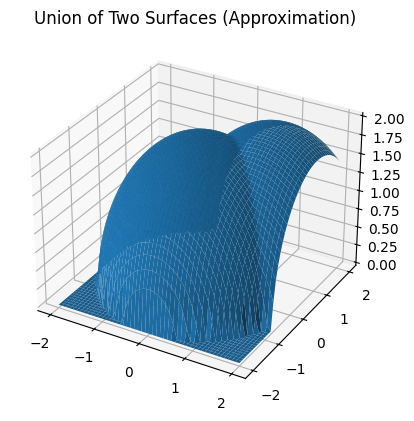

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a grid of (U, V) values
u = np.linspace(-2, 2, 50)
v = np.linspace(-2, 2, 50)
U, V = np.meshgrid(u, v)

# Step 2: Define Surface 1 (a dome / hemisphere)
# Equation: x^2 + y^2 + z^2 = 4  → z = sqrt(4 - x^2 - y^2)
Z1 = np.sqrt(np.maximum(0, 4 - U**2 - V**2))

# Step 3: Define Surface 2 (shifted dome)
# Same shape, but shifted in x and y
Z2 = np.sqrt(np.maximum(0, 4 - (U - 1)**2 - (V - 1)**2))

# Step 4: UNION operation (approximation)
# Take the maximum height at each point
Z_union = np.maximum(Z1, Z2)

# Step 5: Plot the result
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(U, V, Z_union)

ax.set_title("Union of Two Surfaces (Approximation)")
plt.show()

## 2. Difference (Subtraction)

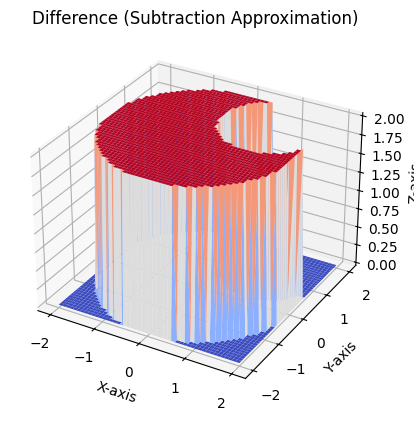

In [8]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-2, 2, 50)
v = np.linspace(-2, 2, 50)
U, V = np.meshgrid(u, v)

Z_base = np.where((U**2 + V**2) < 4, 2, 0)

mask = (U - 1)**2 + (V - 1)**2 < 1

Z_diff = Z_base.copy()
Z_diff[mask] = 0

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(U, V, Z_diff, cmap='coolwarm')

ax.set_title("Difference (Subtraction Approximation)")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

plt.show()

## 3. Intersection

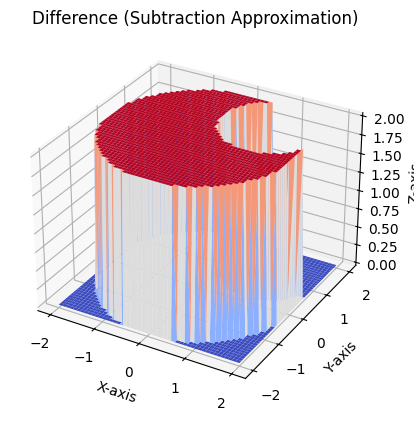

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid of (U, V) coordinates (X-Y plane)
u = np.linspace(-2, 2, 50)
v = np.linspace(-2, 2, 50)
U, V = np.meshgrid(u, v)

# Base shape: circular region with height = 2
# Inside radius 2 → height = 2, outside → 0
Z_base = np.where((U**2 + V**2) < 4, 2, 0)

# Define the region to remove (smaller shifted circle)
# This acts like a cutting tool
mask = (U - 1)**2 + (V - 1)**2 < 1

# Difference operation: remove part of the base shape
Z_diff = Z_base.copy()
Z_diff[mask] = 0

# Plot the resulting surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(U, V, Z_diff, cmap='coolwarm')

ax.set_title("Difference (Subtraction Approximation)")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

plt.show()

## 4. Extrusion (2D to 3D)

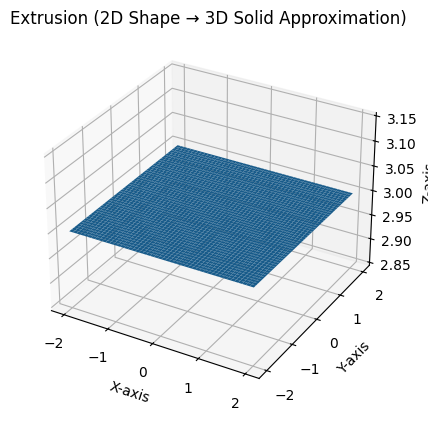

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid of (X, Y) coordinates
# This represents a flat 2D region (like a square base)
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

# Define height (Z) as a constant value
# This means the entire 2D shape is "lifted" to the same height
# This simulates extrusion (stretching a 2D shape into 3D)
Z = np.ones_like(X) * 3

# Plot the extruded surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_title("Extrusion (2D Shape → 3D Solid Approximation)")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

plt.show()

## 5. Revolution

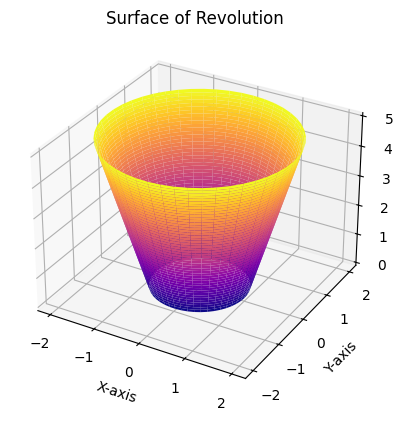

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Create parameters:
# theta → angle around the axis (rotation)
# z → height along the vertical axis
theta = np.linspace(0, 2*np.pi, 50)
z = np.linspace(0, 5, 50)

# Create grid for parameter space
Theta, Z = np.meshgrid(theta, z)

# Define radius as a function of height
# This controls the shape of the object
R = 1 + 0.2 * Z

# Convert from cylindrical → Cartesian coordinates
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Plot the surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='plasma')

ax.set_title("Surface of Revolution")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

plt.show()

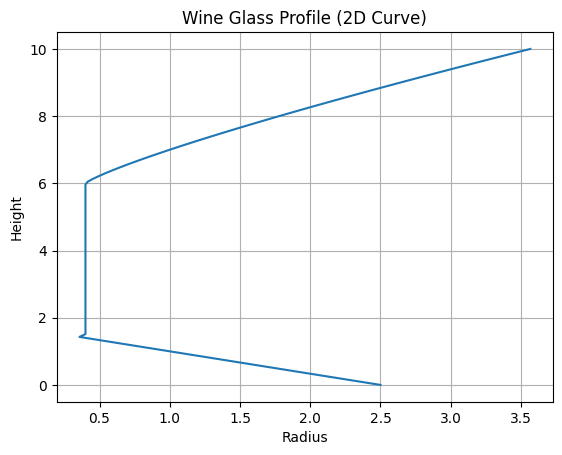

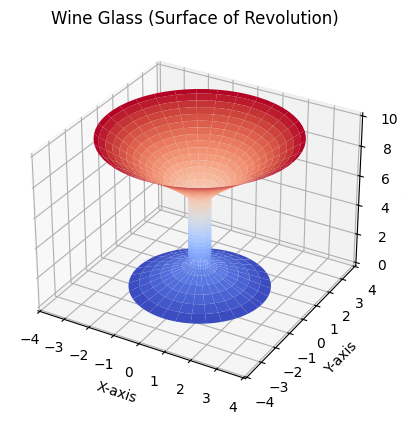

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Create height values (Z-axis)
z = np.linspace(0, 10, 120)

# Define the profile of the wine glass (radius as a function of height)
# This controls how the shape changes from base → stem → bowl
R_profile = np.piecewise(
    z,
    [z < 1.5, (z >= 1.5) & (z < 6), z >= 6],
    [
        lambda z: 2.5 - 1.5*z,          # base tapers inward
        lambda z: 0.4 + 0*z,            # thin vertical stem
        lambda z: 0.4 + 0.6*(z-6)**1.2  # expanding bowl
    ]
)

# Plot the 2D profile curve (design stage)
plt.figure()
plt.plot(R_profile, z)
plt.title("Wine Glass Profile (2D Curve)")
plt.xlabel("Radius")
plt.ylabel("Height")
plt.grid()
plt.show()

# Create angular parameter for rotation
theta = np.linspace(0, 2*np.pi, 60)

# Create grid for surface generation
Theta, Z = np.meshgrid(theta, z)

# Expand radius values across all angles
R = np.tile(R_profile[:, None], (1, len(theta)))

# Convert from cylindrical coordinates to Cartesian coordinates
# This rotates the profile around the Z-axis
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Plot the 3D revolved surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='coolwarm')

ax.set_title("Wine Glass (Surface of Revolution)")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

plt.show()